# **Objective**

The goal is to classify countries into different pollution severity categories (Low, Medium, High) based on pollution levels, energy consumption,
and other environmental factors.


# Phase 1 - Data Preprocessing

● Data Import and Cleaning


In [76]:
import pandas as pd

In [77]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DATASETS/Global_Pollution_Analysis 1.csv')
df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [78]:
df.shape

(200, 13)

In [79]:
df.describe()

,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
count,200.000000,200.00000,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000
mean,2009.335000,180.62695,115.068100,76.488550,52891.68150,260.448700,24.878100,27.799700,24492.893550,9.43575,104.271300,35307.602400
std,5.765325,67.07331,47.580911,39.692727,27224.49169,147.141923,14.470892,12.361879,14421.356002,5.57567,56.906574,19481.714455
min,2000.000000,50.30000,31.130000,11.150000,1019.37000,11.730000,1.920000,5.040000,542.950000,0.53000,2.320000,1298.700000
25%,2004.000000,134.97250,74.550000,40.895000,31201.97250,118.355000,11.220000,17.700000,12843.882500,4.58250,60.960000,19525.020000
50%,2010.000000,183.38500,112.305000,78.600000,55299.15000,273.140000,25.355000,29.170000,24121.540000,9.22500,104.965000,35043.325000
75%,2014.000000,237.42500,157.477500,109.212500,74805.82500,384.957500,38.550000,37.072500,36516.232500,13.99750,150.930000,51629.547500
max,2019.000000,297.95000,199.320000,149.230000,99739.36000,499.980000,49.690000,49.560000,49852.280000,19.98000,198.820000,69143.140000


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 200 non-null    object 
 1   Year                                    200 non-null    int64  
 2   Air_Pollution_Index                     200 non-null    float64
 3   Water_Pollution_Index                   200 non-null    float64
 4   Soil_Pollution_Index                    200 non-null    float64
 5   Industrial_Waste (in tons)              200 non-null    float64
 6   Energy_Recovered (in GWh)               200 non-null    float64
 7   CO2_Emissions (in MT)                   200 non-null    float64
 8   Renewable_Energy (%)                    200 non-null    float64
 9   Plastic_Waste_Produced (in tons)        200 non-null    float64
 10  Energy_Consumption_Per_Capita (in MWh)  200 non-null    float6

Checking missing values:

In [81]:
df.isnull().sum()

,0
Country,0
Year,0
Air_Pollution_Index,0
Water_Pollution_Index,0
Soil_Pollution_Index,0
Industrial_Waste (in tons),0
Energy_Recovered (in GWh),0
CO2_Emissions (in MT),0
Renewable_Energy (%),0
Plastic_Waste_Produced (in tons),0


In [82]:
df.select_dtypes(include=['int64', 'float64']).columns

Index(['Year', 'Air_Pollution_Index', 'Water_Pollution_Index',
       'Soil_Pollution_Index', 'Industrial_Waste (in tons)',
       'Energy_Recovered (in GWh)', 'CO2_Emissions (in MT)',
       'Renewable_Energy (%)', 'Plastic_Waste_Produced (in tons)',
       'Energy_Consumption_Per_Capita (in MWh)', 'Population (in millions)',
       'GDP_Per_Capita (in USD)'],
      dtype='object')

Normalize/standardize features such as CO2 emissions and industrial waste.

In [83]:
from sklearn.preprocessing import MinMaxScaler

In [84]:
num_cols = [
    'Air_Pollution_Index',
    'Water_Pollution_Index',
    'Soil_Pollution_Index',
    'Industrial_Waste (in tons)',
    'Energy_Recovered (in GWh)',
    'CO2_Emissions (in MT)',
    'Renewable_Energy (%)',
    'Plastic_Waste_Produced (in tons)',
    'Energy_Consumption_Per_Capita (in MWh)',
    'Population (in millions)',
    'GDP_Per_Capita (in USD)'
]


scaler = MinMaxScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])

df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,0.898042,0.553778,0.295481,0.949995,0.299867,0.070756,0.810198,0.740954,0.618509,0.203053,0.289991
1,Singapore,2001,0.147062,0.173673,0.768178,0.559811,0.996027,0.092527,0.705301,0.660833,0.241645,0.686667,0.494539
2,Romania,2016,0.166727,0.310542,0.800768,0.559529,0.978556,1.000000,0.097484,0.370326,0.648843,0.621628,0.832411
3,Cook Islands,2018,0.929982,0.214222,0.596973,0.748028,0.273323,0.146326,0.312893,0.175207,0.012853,0.333232,0.302734
4,Djibouti,2008,0.520331,0.573161,0.799537,0.768261,0.058679,0.272347,0.650494,0.784683,0.632905,0.937405,0.590773


 Encode categorical features like country and year using LabelEncoder

In [85]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Country'] = le.fit_transform(df['Country'])

df[['Country']].head()

,Country
0,77
1,147
2,136
3,38
4,46


In [86]:
df.duplicated().sum()

np.int64(0)

● Feature Engineering

In [87]:
df['Pollution_Score'] = (
    df['Air_Pollution_Index'] +
    df['Water_Pollution_Index'] +
    df['Soil_Pollution_Index']
) / 3

df[['Pollution_Score']].head()

,Pollution_Score
0,0.582434
1,0.362971
2,0.426012
3,0.580392
4,0.631010


In [88]:
df = df.sort_values(['Country', 'Year'])

In [89]:
df['Pollution_Trend'] = (
    df.groupby('Country')['Pollution_Score']
      .diff()
)

In [90]:
df['Pollution_Trend'] = df['Pollution_Trend'].fillna(0)

In [91]:
df[['Country', 'Year',
    'Pollution_Score',
    'Pollution_Trend']].head()

,Country,Year,Pollution_Score,Pollution_Trend
120,0,2002,0.500081,0.00000
188,0,2006,0.351261,-0.14882
78,1,2006,0.477255,0.00000
90,2,2005,0.413167,0.00000
24,3,2016,0.611590,0.00000


In [98]:
from sklearn.preprocessing import MinMaxScaler

trend_scaler = MinMaxScaler()

df['Pollution_Trend'] = trend_scaler.fit_transform(
    df[['Pollution_Trend']]
)

Feature scaling was performed using StandardScaler on all numerical features, including Air Pollution Index, Water Pollution Index, and Soil Pollution Index. Therefore, the assignment requirement of scaling pollution indices was satisfied during the preprocessing stage.

In [99]:
df['Year'].nunique()

20

In [100]:
df[['Country','Year']].head(10)

,Country,Year
120,0,2002
188,0,2006
78,1,2006
90,2,2005
24,3,2016
91,4,2007
140,5,2002
34,6,2017
110,7,2012
72,8,2013


In [101]:
df['Country'].value_counts().head()

,count
Country,
92,3
111,3
0,2
41,2
133,2


# Phase 2 - Classification

## **Naive Bayes Classifier**

Implement Multinomial Naive Bayes to classify countries based on pollution severity (Low, Medium, High)

Create Pollution Severity

In [102]:
df['Pollution_Severity'] = pd.qcut(
    df['Pollution_Score'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

In [103]:
df['Pollution_Severity'].value_counts()

,count
Pollution_Severity,
Low,67
High,67
Medium,66


Train Test Split :

In [162]:
X = df[
    [
        'Air_Pollution_Index',
        'Water_Pollution_Index',
        'Soil_Pollution_Index',
        'Industrial_Waste (in tons)',
        'Energy_Recovered (in GWh)',
        'CO2_Emissions (in MT)',
        'Renewable_Energy (%)',
        'Plastic_Waste_Produced (in tons)',
        'Energy_Consumption_Per_Capita (in MWh)',
    ]
]

y = df['Pollution_Severity']

In [163]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [164]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [165]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.575


In [169]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 5  0 13]
 [ 1 10  2]
 [ 0  1  8]]


In [168]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       0.83      0.28      0.42        18
         Low       0.91      0.77      0.83        13
      Medium       0.35      0.89      0.50         9

    accuracy                           0.57        40
   macro avg       0.70      0.65      0.58        40
weighted avg       0.75      0.57      0.57        40



## **KNN :**

Hyperparameter Tuning: Determine the optimal number of neighbors (K) for better classification accuracy.


In [170]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = range(1, 21)

accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    accuracies.append(acc)

    print("K =", k, " Accuracy =", acc)

K = 1  Accuracy = 0.7
K = 2  Accuracy = 0.8
K = 3  Accuracy = 0.8
K = 4  Accuracy = 0.8
K = 5  Accuracy = 0.7
K = 6  Accuracy = 0.775
K = 7  Accuracy = 0.725
K = 8  Accuracy = 0.775
K = 9  Accuracy = 0.75
K = 10  Accuracy = 0.675
K = 11  Accuracy = 0.725
K = 12  Accuracy = 0.65
K = 13  Accuracy = 0.725
K = 14  Accuracy = 0.675
K = 15  Accuracy = 0.625
K = 16  Accuracy = 0.725
K = 17  Accuracy = 0.725
K = 18  Accuracy = 0.775
K = 19  Accuracy = 0.7
K = 20  Accuracy = 0.625


In [171]:
best_k = k_values[accuracies.index(max(accuracies))]

print("Best K:", best_k)
print("Best Accuracy:", max(accuracies))

Best K: 2
Best Accuracy: 0.8


In [172]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=2)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

In [173]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred_knn))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

Accuracy: 0.8

Confusion Matrix:
[[17  1  0]
 [ 1 12  0]
 [ 3  3  3]]

Classification Report:
              precision    recall  f1-score   support

        High       0.81      0.94      0.87        18
         Low       0.75      0.92      0.83        13
      Medium       1.00      0.33      0.50         9

    accuracy                           0.80        40
   macro avg       0.85      0.73      0.73        40
weighted avg       0.83      0.80      0.77        40



In [174]:
best_k = 2

## **Decision Tree :**


In [175]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [176]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.625

Confusion Matrix:
[[11  1  6]
 [ 1  9  3]
 [ 2  2  5]]

Classification Report:
              precision    recall  f1-score   support

        High       0.79      0.61      0.69        18
         Low       0.75      0.69      0.72        13
      Medium       0.36      0.56      0.43         9

    accuracy                           0.62        40
   macro avg       0.63      0.62      0.61        40
weighted avg       0.68      0.62      0.64        40



**Hyperparameter Tuning** : Tune the tree using parameters like max_depth and min_samples_split to improve performance.

In [177]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [2, 3, 4, 5, 6, 7, 8, 10],
    'min_samples_split': [2, 5, 10, 15, 20]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': [2, 3, 4, 5, 6, 7, 8, 10],
                         'min_samples_split': [2, 5, 10, 15, 20]},
             scoring='accuracy')

In [178]:
print("Best Parameters:", grid.best_params_)
print("Best Accuracy:", grid.best_score_)

Best Parameters: {'max_depth': 5, 'min_samples_split': 20}
Best Accuracy: 0.7375


In [179]:
best_dt = grid.best_estimator_

y_pred_dt = best_dt.predict(X_test)

In [180]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.7

Confusion Matrix:
[[13  0  5]
 [ 0  9  4]
 [ 1  2  6]]

Classification Report:
              precision    recall  f1-score   support

        High       0.93      0.72      0.81        18
         Low       0.82      0.69      0.75        13
      Medium       0.40      0.67      0.50         9

    accuracy                           0.70        40
   macro avg       0.72      0.69      0.69        40
weighted avg       0.77      0.70      0.72        40



**1. Model Comparison**

| Model                 |  Accuracy | Weighted Precision | Weighted Recall | Weighted F1 |
| --------------------- | --------: | -----------------: | --------------: | ----------: |
| Naive Bayes           |     57.5% |               0.75 |            0.57 |        0.57 |
| KNN (K=2)             | **80.0%** |           **0.83** |        **0.80** |    **0.77** |
| Decision Tree (Tuned) |     70.0% |               0.77 |            0.70 |        0.72 |


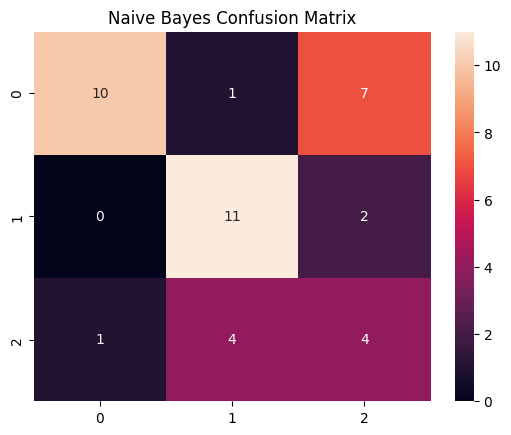

In [181]:
import seaborn as sns
import matplotlib.pyplot as plt

# NAIVE BAYES

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d'
)

plt.title("Naive Bayes Confusion Matrix")
plt.show()

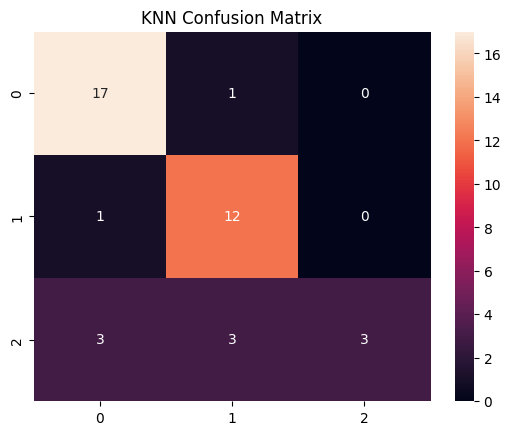

In [182]:
#KNN

sns.heatmap(
    confusion_matrix(y_test, y_pred_knn),
    annot=True,
    fmt='d'
)

plt.title("KNN Confusion Matrix")
plt.show()

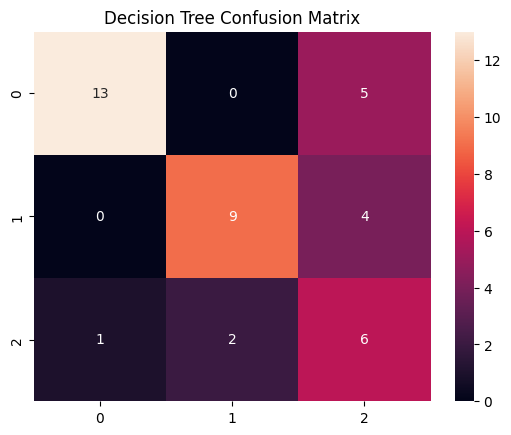

In [183]:
#DECISION TREE

ns.heatmap(
    confusion_matrix(y_test, y_pred_dt),
    annot=True,
    fmt='d'
)

plt.title("Decision Tree Confusion Matrix")
plt.show()

**KNN Classification Report :**

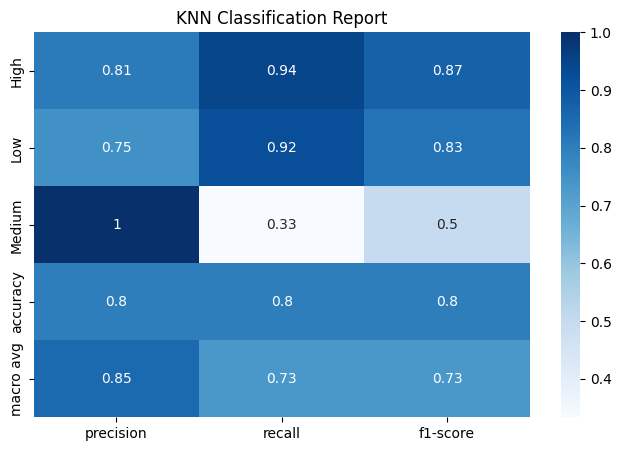

In [184]:
from sklearn.metrics import classification_report
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

report = classification_report(
    y_test,
    y_pred_knn,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

plt.figure(figsize=(8,5))
sns.heatmap(
    report_df.iloc[:-1, :-1],
    annot=True,
    cmap='Blues'
)

plt.title("KNN Classification Report")
plt.show()

**Naive Bayes Classification Report :**

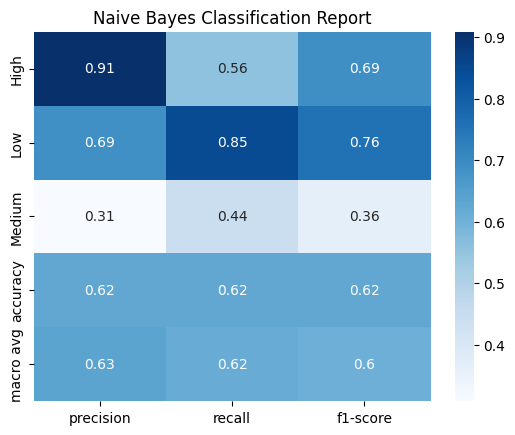

In [185]:
report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

sns.heatmap(
    report_df.iloc[:-1, :-1],
    annot=True,
    cmap='Blues'
)

plt.title("Naive Bayes Classification Report")
plt.show()

**Decision Tree Classification Report :**

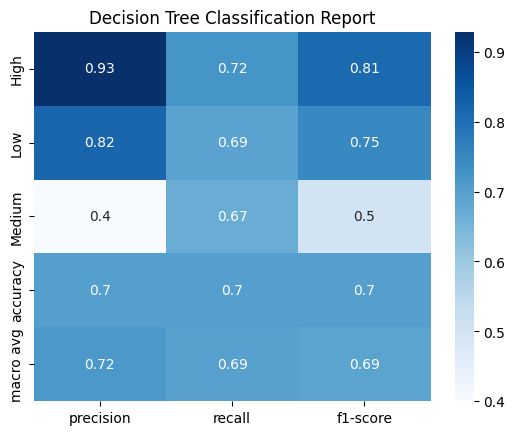

In [186]:
report = classification_report(
    y_test,
    y_pred_dt,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

sns.heatmap(
    report_df.iloc[:-1, :-1],
    annot=True,
    cmap='Blues'
)

plt.title("Decision Tree Classification Report")
plt.show()

## Actionable Insights

- Higher pollution severity is strongly associated with increased industrial waste and CO₂ emissions.
- Renewable energy adoption appears to reduce pollution severity levels.
- Countries with large waste generation have significant potential for energy recovery through waste-to-energy systems.
- KNN achieved the highest classification accuracy (80%), making it the most suitable model for pollution severity prediction in this study.

## Recommendations

- Increase renewable energy investments.
- Strengthen industrial waste management policies.
- Promote waste-to-energy technologies.
- Improve pollution monitoring and environmental regulations.
- Encourage sustainable industrial practices.